In [1]:
import tempfile
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from aeon.datasets import load_classification
from tscglue.models import TSCGlueEnhancedV4

OUT = Path("../generated_results/088-level-timing")
OUT.mkdir(parents=True, exist_ok=True)

In [2]:
# # Fit best/log_loss on 1 CPU, no GPU. Per dataset, write every recorded time
# # (feature transforms + each fold of each L0/L1/L2 model) plus the wall-clock fit.
# # Skips datasets that already have a CSV; comment this cell out to only analyse finished ones.
# datasets = sorted(p.name for p in Path("../data").iterdir() if p.is_dir())
# for ds in datasets:
#     path = OUT / f"{ds}.csv"
#     if path.exists():
#         continue
#     X_train, y_train = load_classification(ds, split="train", extract_path="../data")
#     with tempfile.TemporaryDirectory() as runs_dir:
#         clf = TSCGlueEnhancedV4(
#             verbose=10, random_state=0, n_jobs=1, n_gpus=0,
#             eval_metric="log_loss", preset="best", runs_dir=runs_dir,
#         )
#         t0 = time.perf_counter()
#         clf.fit(X_train, y_train)
#         fit_s = time.perf_counter() - t0
#         fallback = clf._fallback_path.exists()  # before runs_dir is deleted
#     rows = clf.summary(return_transforms=True)
#     df = pd.DataFrame(
#         [{"model": r["model"], "level": r["level"], "fold": i, "time_s": t}
#          for r in rows for i, t in enumerate(r["train_time"])]
#     )
#     df["dataset"] = ds
#     df["n_train"], df["length"] = X_train.shape[0], X_train.shape[-1]
#     df["n_classes"] = len(set(y_train))
#     df["fit_wall_s"] = fit_s
#     df["fallback"] = fallback
#     df.to_csv(path, index=False)
#     print(f"{ds}: fit {fit_s:.1f}s -> {path}")

In [3]:
# Only datasets whose fit has finished (CSV written).
done = sorted(p.stem for p in OUT.glob("*.csv"))
df = pd.concat([pd.read_csv(OUT / f"{ds}.csv") for ds in done])
# Drop datasets where tscglue fell back to a single classifier (too few samples per class):
# they have no L1/L2/L3 rows, so their stage shares are not comparable.
stacked = df.loc[df["level"].notna(), "dataset"].unique()
df = df[df["dataset"].isin(stacked)]
# Paper numbering: L0 = representations (tscglue level NaN), L1 = base models (level 0),
# L2 = stackers (level 1), L3 = meta stacker (level 2).
df["stage"] = df["level"].map({0: "L1", 1: "L2", 2: "L3"}).fillna("L0")

per_ds = df.pivot_table(index="dataset", columns="stage", values="time_s", aggfunc="sum")
per_ds = per_ds[["L0", "L1", "L2", "L3"]]
per_ds["overhead"] = df.groupby("dataset")["fit_wall_s"].first() - per_ds.sum(axis=1)
per_ds["wall"] = df.groupby("dataset")["fit_wall_s"].first()
share = per_ds.drop(columns="wall").div(per_ds["wall"], axis=0) * 100
display(df.groupby("dataset")[["n_train", "length", "n_classes", "fallback"]].first())
display(per_ds.round(1))
share.round(1)

/tmp/ipykernel_2533877/2214270205.py:3: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([pd.read_csv(OUT / f"{ds}.csv") for ds in done])


,n_train,length,n_classes,fallback
dataset,,,,
ACSF1,100,1460,10,False
Adiac,390,176,37,False
ArrowHead,36,251,3,False
BME,30,128,3,False
Beef,30,470,5,False
...,...,...,...,...
Wine,57,234,2,False
WordSynonyms,267,270,25,False
Worms,181,900,5,False


stage,L0,L1,L2,L3,overhead,wall
dataset,,,,,,
ACSF1,50.4,45.7,30.0,8.3,1.9,136.3
Adiac,46.0,158.0,6865.4,17.7,2.3,7089.5
ArrowHead,21.8,13.5,22.7,7.2,1.7,66.8
BME,20.0,11.7,21.0,7.1,1.7,61.5
Beef,22.4,15.4,23.2,7.3,1.7,69.9
...,...,...,...,...,...,...
Wine,22.5,14.7,19.5,6.6,1.7,65.0
WordSynonyms,81.9,124.5,65.2,12.6,2.7,286.9
Worms,54.3,63.7,30.3,8.4,1.8,158.6


stage,L0,L1,L2,L3,overhead
dataset,,,,,
ACSF1,37.0,33.6,22.0,6.1,1.4
Adiac,0.6,2.2,96.8,0.2,0.0
ArrowHead,32.7,20.2,33.9,10.7,2.5
BME,32.5,19.0,34.2,11.6,2.7
Beef,32.0,22.0,33.2,10.4,2.4
...,...,...,...,...,...
Wine,34.7,22.6,29.9,10.2,2.6
WordSynonyms,28.5,43.4,22.7,4.4,1.0
Worms,34.3,40.2,19.1,5.3,1.2


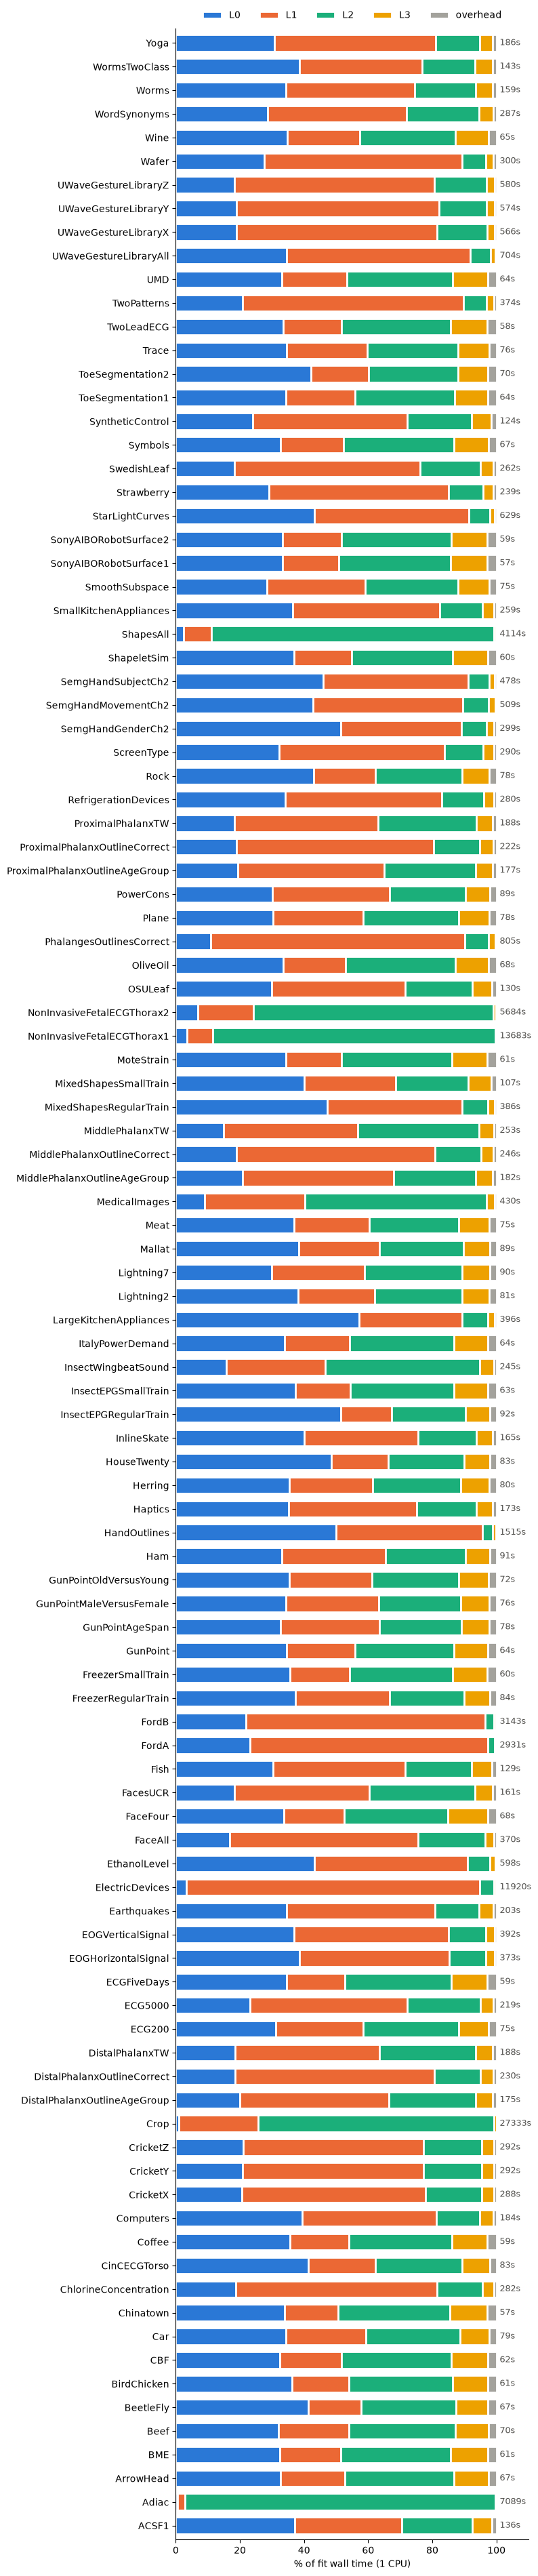

In [4]:
STAGE_COLORS = {"L0": "#2a78d6", "L1": "#eb6834", "L2": "#1baf7a", "L3": "#eda100", "overhead": "#a3a29c"}

fig, ax = plt.subplots(figsize=(8, 0.35 * len(share) + 1))
share[list(STAGE_COLORS)].plot.barh(
    stacked=True, ax=ax, color=list(STAGE_COLORS.values()), width=0.7, edgecolor="white", linewidth=2
)
for i, wall in enumerate(per_ds["wall"]):
    ax.text(101, i, f"{wall:.0f}s", va="center", fontsize=9, color="#52514e")
ax.set_xlim(0, 110)
ax.set_xlabel("% of fit wall time (1 CPU)")
ax.set_ylabel("")
ax.legend(ncol=5, loc="lower center", bbox_to_anchor=(0.5, 1.0), frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

stage
L0 GPU-capable    16.1
L0                14.0
L1                36.6
L2                25.7
L3                 6.1
overhead           1.5
dtype: float64

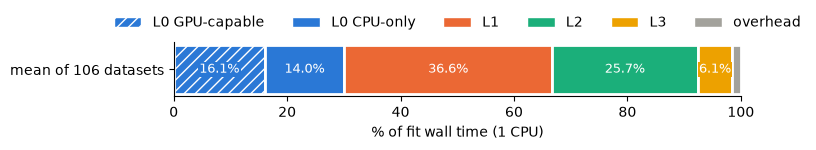

In [5]:
# All datasets in one bar: per-dataset percentages averaged, so each dataset counts equally.
# L0 is split into the feature transforms that have a GPU path in tscglue
# (hydra, mantis, chronos2) and the other representations, which are CPU-only.
GPU_FEATURES = ("hydra", "mantis", "chronos2")
is_gpu = df["level"].isna() & df["model"].str.replace(r"_s_\d+$", "", regex=True).isin(GPU_FEATURES)
gpu_share = df[is_gpu].groupby("dataset")["time_s"].sum() / per_ds["wall"] * 100

split = share[list(STAGE_COLORS)].copy()
split.insert(0, "L0 GPU-capable", gpu_share)
split["L0"] -= split["L0 GPU-capable"]
mean_split = split.mean()
assert abs(mean_split.sum() - 100) < 1e-9

fig, ax = plt.subplots(figsize=(8, 1.6))
left = 0
for stage, value in mean_split.items():
    color = STAGE_COLORS["L0" if stage == "L0 GPU-capable" else stage]
    hatch = "///" if stage == "L0 GPU-capable" else None
    ax.barh(0, value, left=left, color=color, hatch=hatch, height=0.6, edgecolor="white", linewidth=2)
    if value >= 4:
        ax.text(left + value / 2, 0, f"{value:.1f}%", ha="center", va="center", fontsize=9, color="white",
                bbox=dict(facecolor=color, edgecolor="none", pad=1))
    left += value
ax.set_xlim(0, 100)
ax.set_yticks([0], [f"mean of {len(split)} datasets"])
ax.set_xlabel("% of fit wall time (1 CPU)")
legend = [("L0 GPU-capable", STAGE_COLORS["L0"], "///"), ("L0 CPU-only", STAGE_COLORS["L0"], None)]
legend += [(s, c, None) for s, c in STAGE_COLORS.items() if s != "L0"]
ax.legend(
    handles=[plt.Rectangle((0, 0), 1, 1, facecolor=c, hatch=h, edgecolor="white") for _, c, h in legend],
    labels=[s for s, _, _ in legend], ncol=6, loc="lower center", bbox_to_anchor=(0.5, 1.0), frameon=False,
)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig("figures2/level_time_share_1cpu.pdf", bbox_inches="tight", pad_inches=0)
mean_split.round(1)



In [6]:
# Per model: total seconds summed over folds, coloured by stage.
per_model = df.groupby(["dataset", "stage", "model"])["time_s"].sum().reset_index()

fig, axes = plt.subplots(1, len(per_ds), figsize=(4.5 * len(per_ds), 8), sharey=True)
order = per_model.groupby("model")["time_s"].sum().sort_values().index
for ax, (ds, g) in zip(axes, per_model.groupby("dataset")):
    g = g.set_index("model").reindex(order)
    ax.barh(g.index, g["time_s"], color=g["stage"].map(STAGE_COLORS))
    ax.set_title(f"{ds} ({per_ds.loc[ds, 'wall']:.0f}s)", fontsize=10)
    ax.set_xlabel("seconds (sum over folds)")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(
    handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in STAGE_COLORS.values() if c != "#a3a29c"],
    labels=[s for s in STAGE_COLORS if s != "overhead"], loc="lower right", frameon=False,
)
plt.tight_layout()